In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns

In [2]:
dataset_path = "../archive/mental_health.csv"
dataset = pd.read_csv(dataset_path)
dataset = dataset[dataset['Has_Mental_Health_Issue'] == 1].copy()

print(dataset.columns.tolist())
drop_column = ['Age', 'Gender', 'Country', 'Education', 'Country', 'Social_Media_Hours_Day', 'Feeling_Sad_Down', 
               'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue', 
               'Poor_Appetite_Or_Overeating', 'Irritability', 'Obsessive_Thoughts', 
               'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts', 
               'Family_History_Mental_Illness', 'Previously_Diagnosed', 'Ever_Sought_Treatment', 
               'On_Therapy_Now', 'On_Medication', 'Trauma_History', 'Feeling_Worthless', 
               'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks', 
               'Mood_Swings', 'Has_Mental_Health_Issue'] 

['Age', 'Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level', 'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency', 'Smoking', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day', 'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress', 'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue', 'Poor_Appetite_Or_Overeating', 'Feeling_Worthless', 'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks', 'Mood_Swings', 'Irritability', 'Obsessive_Thoughts', 'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts', 'Family_History_Mental_Illness', 'Previously_Diagnosed', 'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication', 'Trauma_History', 'Social_Support', 'Close_Friends_Count', 'Feel_Understood', 'Loneliness', 'Discuss_Mental_Health', 

In [3]:
columns_to_drop = [col for col in drop_column if col in dataset.columns]
df = dataset.drop(columns=columns_to_drop)
df = df.dropna()

In [4]:
# Work_Hours_Per_Week, Job_Satisfaction, Work_Stress_Level, Work_Life_Balance, Company_Mental_Health_Support
hours_min = df['Work_Hours_Per_Week'].min()
hours_max = df['Work_Hours_Per_Week'].max()

def map_value(x):
    if x == "No":
        return 2
    elif x == "Not Sure":
        return 1
    else:
        return 0
    
hours_ratio = (df['Work_Hours_Per_Week'] - hours_min) / (hours_max - hours_min)

dissatisfaction_ratio = (11 - df['Job_Satisfaction']) / 10

interaction_burden = (hours_ratio * dissatisfaction_ratio) * 4

df['Work_Score'] = (
    interaction_burden + 
    (df['Work_Stress_Level'] / 10) * 2 + 
    (2 - (df['Work_Life_Balance'] / 10) * 2) + 
    (df['Company_Mental_Health_Support'].apply(map_value))
)

In [5]:
# Income_Level, Financial_Stress, Employment_Status, Marital_Status
def map_employment(x):
    if x == "Unemployed":
        return 2.5
    elif x in ["Student", "Part-time"]:
        return 1.0
    else:
        return 0.0

def map_income(x):
    if x == "Low":
        return 1.5
    elif x == "Medium":
        return 0.5
    else:
        return 0.0

def get_marital_penalty(row):
    if row['Marital_Status'] in ["Married", "Divorced"]:
        if row['Employment_Status'] == "Unemployed" or row['Income_Level'] == "Low":
            return 1.0
    return 0.0

df['Financial_Score'] = (
    (df['Financial_Stress'] / 10) * 5 + 
    df['Employment_Status'].apply(map_employment) +
    df['Income_Level'].apply(map_income) +
    df.apply(get_marital_penalty, axis=1)
)

In [6]:
# Ever_Bullied_At_Work, Social_Support, Close_Friends_Count, Loneliness, Feel_Understood, Discuss_Mental_Health, Remote_Work
close_friend_max = df['Close_Friends_Count'].max()
close_friend_min = df['Close_Friends_Count'].min()
friend_ratio = (df['Close_Friends_Count'] - close_friend_min) / (close_friend_max - close_friend_min)
lack_of_friends_score = (1 - friend_ratio) * 1.0

def map_discuss(x):
    if x == "Never":
        return 1.0
    elif x == "Rarely":
        return 0.75
    elif x == "Sometimes":
        return 0.5
    else:
        return 0.0

def get_isolation_penalty(row):
    if row['Remote_Work'] == "Yes" and row['Loneliness'] >= 6:
        return 1.0
    return 0.0

df['Social_Score'] = (
    (df['Loneliness'] / 10) * 2.5 +
    (2.0 - (df['Feel_Understood'] / 10) * 2.0) +

    (1.5 - (df['Social_Support'] / 10) * 1.5) + 
    df['Discuss_Mental_Health'].apply(map_discuss) +

    lack_of_friends_score +
    df.apply(get_isolation_penalty, axis=1) +

    np.where(df['Ever_Bullied_At_Work'] == 1, 2.0, 0)
)

df['Social_Score'] = df['Social_Score'] * 0.9

In [7]:
# Exercise_Per_Week, Sleep_Hours_Night, Caffeine_Drinks_Day, Alcohol_Frequency, Smoking, Screen_Time_Hours_Day, Hobby_Time_Hours_Week, Diet_Quality
def sleep_score(x):
    optimal = 7.5
    if x < optimal:
        penalty = (optimal - x) / 4.0
    else:
        penalty = (x - optimal) / 6.0
    return min(2.5, max(0, penalty * 2.5))

def mapping_diet(x):
    if x in ["Excellent", "Good"]: return 0.0
    elif x == "Average": return 0.4
    else: return 1.5

def mapping_exercise(x):
    if x in ["5+ Times", "3-4 Times"]: return 0.0
    elif x == "1-2 Times": return 0.4 
    else: return 1.5

def mapping_alcohol(x):
    if x == "Never": return 0.0
    elif x == "Rarely": return 0.3
    elif x == "Weekly": return 0.6
    else: return 1.0

def mapping_smoking(x):
    if x == "Never": return 0.0
    elif x == "Former": return 0.2
    else: return 0.5

df['Lifestyle_Score'] = (
    df['Sleep_Hours_Night'].apply(sleep_score) +
    df['Diet_Quality'].apply(mapping_diet) +
    df['Exercise_Per_Week'].apply(mapping_exercise) +
    df['Alcohol_Frequency'].apply(mapping_alcohol) +
    df['Smoking'].apply(mapping_smoking) +
    
    df['Caffeine_Drinks_Day'].apply(lambda x: min(0.5, (max(0, x - 2) / 2.0) * 0.5)) +
    df['Screen_Time_Hours_Day'].apply(lambda x: min(1.5, (max(0, x - 6) / 4.0) * 1.5)) +
    df['Hobby_Time_Hours_Week'].apply(lambda x: max(0, 1.0 - (x / 3.0)))
)

In [8]:
cause_category = ['Work_Score', 'Financial_Score', 'Social_Score', 'Lifestyle_Score']

df['Target_Cause'] = df[cause_category].idxmax(axis=1)

df = df.drop(columns=cause_category)

print(df['Target_Cause'].value_counts())

Target_Cause
Financial_Score    2543
Work_Score         2538
Social_Score       2493
Lifestyle_Score    1642
Name: count, dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9216 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Marital_Status                 9216 non-null   object 
 1   Income_Level                   9216 non-null   object 
 2   Employment_Status              9216 non-null   object 
 3   Work_Hours_Per_Week            9216 non-null   int64  
 4   Remote_Work                    9216 non-null   object 
 5   Job_Satisfaction               9216 non-null   int64  
 6   Work_Stress_Level              9216 non-null   int64  
 7   Work_Life_Balance              9216 non-null   int64  
 8   Ever_Bullied_At_Work           9216 non-null   int64  
 9   Company_Mental_Health_Support  9216 non-null   object 
 10  Exercise_Per_Week              9216 non-null   object 
 11  Sleep_Hours_Night              9216 non-null   float64
 12  Caffeine_Drinks_Day            9216 non-null   int64 

In [10]:
print(df.columns.tolist())

['Marital_Status', 'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level', 'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency', 'Smoking', 'Screen_Time_Hours_Day', 'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress', 'Social_Support', 'Close_Friends_Count', 'Feel_Understood', 'Loneliness', 'Discuss_Mental_Health', 'Target_Cause']


In [11]:
X = df.drop(columns=['Target_Cause'])
Y = df['Target_Cause']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

In [12]:
label_mapping = {
    'Work_Score': 0,
    'Financial_Score': 1,
    'Social_Score': 2,
    'Lifestyle_Score': 3
}
Y_encoded = Y.map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(X, Y_encoded, test_size=0.2, random_state=42)

In [13]:
model = lgb.LGBMClassifier(
    random_state=42,
    learning_rate=0.05,
    class_weight='balanced',
    n_estimators=400,
    num_leaves=40
    )

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 456
[LightGBM] [Info] Number of data points in the train set: 7372, number of used features: 24
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=400,
               num_leaves=40, random_state=42)

In [14]:
y_pred = model.predict(X_test)

accuarcy = accuracy_score(y_test, y_pred) * 100

target_names = ['Work', 'Financial', 'Social', 'Lifestyle']
print(f"Accuracy : {accuarcy:.2f}%")
print("\n=== Model Evaluation Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy : 90.94%

=== Model Evaluation Report ===
              precision    recall  f1-score   support

        Work       0.94      0.92      0.93       530
   Financial       0.91      0.93      0.92       504
      Social       0.89      0.92      0.90       499
   Lifestyle       0.90      0.84      0.87       311

    accuracy                           0.91      1844
   macro avg       0.91      0.90      0.91      1844
weighted avg       0.91      0.91      0.91      1844



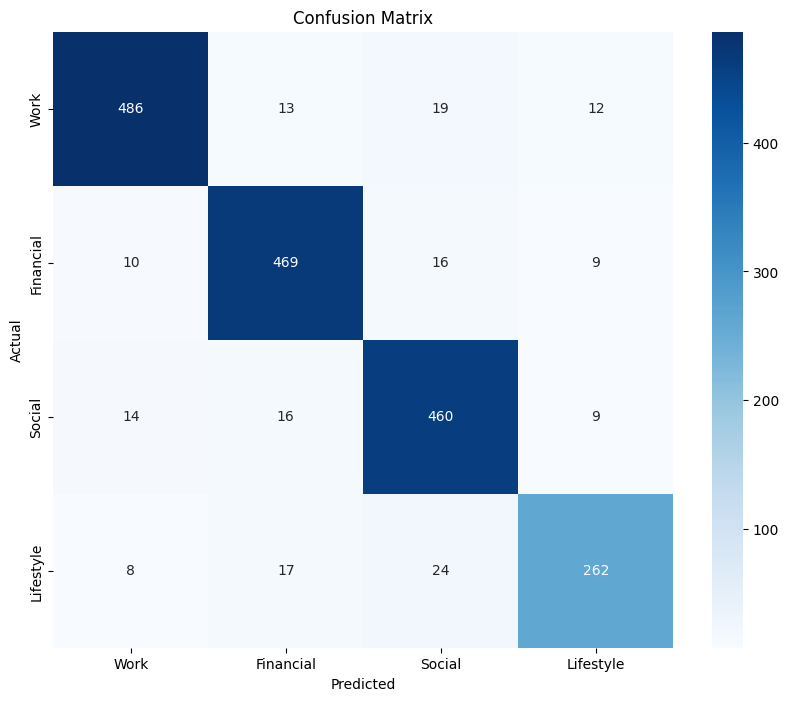

In [15]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()